<a href="https://colab.research.google.com/github/SimoneZangla/SimoZ/blob/Materiale/SocketUDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Socket UDP (Teoria presa dal libro di "Paolo Camagni e Riccardo Nikolassy" dal tittolo "NUOVO TECNOLOGIE E PROGETTAZIONE DI SISTEMI INFORMATICI E DI TELECOMUNICAZIONI 3")

Il protocollo UDP ha caratteristiche diverse dal protocollo TCP: UDP non è orientato alla connessione e quindi tra due
host non si crea uno stream stabile.
L’avvio di una comunicazione avviene senza handshaking e la consegna non è garantita; al contrario i controlli sull’in
tegrità vengono eseguiti come in TCP.
Uno dei principali vantaggi di UDP è che, grazie alla sua semplicità off re un servizio molto rapido e non richiede han
dshaking (per questo viene spesso utilizzato per DNS).
In questa esercitazione realizzeremo la comunicazione mediante protocollo UDP dove un mittente (UDPClient.java)
trasmette un messaggio (datagram) a un destinatario (UDPServer.java).

Ricordiamo che, in una comunicazione dati “connectionless o datagram”, il canale:
*  trasporta messaggi;
*  non è affi  dabile;
*  ha il socket condiviso;
*  non preserva l’ordine delle informazioni.

**Inoltre l’ordine di arrivo dei pacchetti non è necessariamente lo stesso di invio.**

Realizzare un sistema client-server UDP consiste nell’implementare un programma che eff ettui i seguenti passi fon
damentali.

Per il client:
*  crea il socket;
*  manda richiesta sul socket (composto da indirizzo, porta e messaggio);
*  riceve dati dal socket;
*  chiude il socket.

Per il server:
*   crea il socket;
*   ripete le seguenti operazioni:
1.   si mette in attesa delle richieste in arrivo;
2.   riceve il messaggio dal socket;
3.   invia la risposta sul socket al client che ha fatto una richiesta;

*  chiude il socket.

**La comunicazione UDP viene realizzata in Java mediante la classe DatagramSocket.**

**CLASSE DATAGRAMSOCKET**

La classe Java DatagramSocket usa il protocollo UDP per trasmettere dati attraverso i socket: permette a un client di con
nettersi a una determinata porta di un host per leggere e scrivere dati impacchettati attraverso la classe DatagramPacket.

**L’indirizzo dell’host destinatario è sul DatagramPacket.**

I principali metodi della DatagramSocket(..) sono i seguenti:
*   Metodi costruttor:




In [ ]:
void DatagramSocket() throws SocketException
 void DatagramSocket(int porta) throws SocketException

*  Metodi per ricevere/trasmettere:




In [ ]:
 void send(DatagramPacket pacchettoDati) throws IOException
 void receive(DatagramPacket pacchettoDati) throws IOException

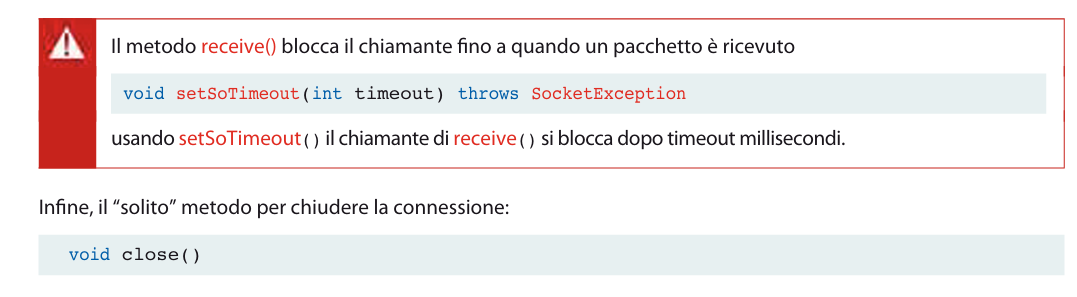

**CLASSE DATAGRAMPACKET**

La classe DatagramPacket è la classe Java che permette di rappresentare i pacchetti UDP da inviare e ricevere sui
socket di tipo datagram.

Il costruttore della classe è il seguente:

In [ ]:
 public DatagramPacket(byte buff er[], int lunghezza, InetAddress indirizzo, int porta);

Il client crea un oggetto di DatagramPacket passando al costruttore:

*  il contenuto del messaggio: un array di lunghezza caratteri;
*  l’indirizzoIP del server;
*  il numero di porta su cui il server è in ascolto.





 Il server, per ricevere un messaggio, crea un oggetto di DatagramPacket defi nendone la lunghezza massima:

In [ ]:
public DatagramPacket(byte buff er[], int lunghezza);

 I principali metodi della classe DatagramPacket sono:

1. Per la gestione dell’indirizzo IP:

In [ ]:
 void setAddress(InetAddress indirizzo); //setta il valore dell’indirizzo IP;
 InetAddress getAddress(); //restituisce l’indirizzo IP del’host da cui il pacchetto è stato ricevuto.

2.  Per la gestione della porta:

In [ ]:
void setPort(int porta); //setta il valore della porta;
 int getPort(); // restituisce la porta della macchina remota da cui il pacchetto è stato ricevuto.

3.   Per la gestione dei dati:

In [ ]:
 void setData(byte[] buff er); //inserisce i dati nel pacchetto;
 byte[] getData(); //restituisce i dati del pacchetto.

# Esercitazione Socket UDP Mono-Client Echo

**CREAZIONE DEL SERVER UDP**

**1. Creazione del socket UDP**




In [ ]:
import java.io.IOException;
import java.net.DatagramPacket;
import java.net.DatagramSocket;
import java.net.InetAddress;
import java.nio.charset.StandardCharsets;
public class Server {
    public static void main(String[] args) throws IOException {
        DatagramSocket socket = new DatagramSocket(12345);

*  Viene creato un socket UDP associato alla porta 12345. Questo socket sarà utilizzato per ricevere pacchetti daL client.




**2. Preparazione per ricevere un pacchetto**

In [ ]:
byte[] buf = new byte[256];
DatagramPacket packet = new DatagramPacket(buf, buf.length);
socket.receive(packet);

*  Viene creato un buffer (buf) per contenere i dati ricevuti.
*  Un oggetto DatagramPacket viene inizializzato con questo buffer.
*  Il metodo socket.receive(packet) blocca l'esecuzione del programma finché non viene ricevuto un pacchetto. Quando arriva un pacchetto:
  *   I dati vengono memorizzati in buf.
  *   Informazioni aggiuntive (come indirizzo IP e porta del mittente) vengono memorizzate nel pacchetto.








**3. Stampa del contenuto del pacchetto ricevuto**

In [ ]:
System.out.println(new String(packet.getData(), 0, packet.getLength(), StandardCharsets.UTF_8));

*   I dati ricevuti nel pacchetto vengono estratti e convertiti in una stringa utilizzando la codifica UTF-8.
*   La stringa risultante viene stampata sulla console.

**4. Preparazione e invio di un pacchetto di risposta**

In [ ]:
InetAddress destAddress = InetAddress.getByName("localhost");
int destPort = 4445;
DatagramPacket packet2 = new DatagramPacket(packet.getData(), packet.getLength(), destAddress, destPort);
socket.send(packet2);

*   L'indirizzo di destinazione (localhost) e la porta (4445) vengono impostati. Questo indirizzo e porta corrispondono al client che ha inviato il pacchetto.
*   Un nuovo pacchetto (packet2) viene creato utilizzando:
   *  I dati ricevuti dal client (stessi dati di packet).
   *  L'indirizzo (destAddress) e la porta (destPort) del client.
*  Il pacchetto di risposta viene inviato con il metodo socket.send(packet2).







**5. Chiusura del socket**

In [ ]:
socket.close();
  }
}

*  Dopo aver inviato la risposta, il socket viene chiuso per liberare le risorse.




**CREAZIONE DEL CLIENT UDP**

**1. Creazione del socket UDP**

In [ ]:
import java.io.IOException;
import java.net.DatagramPacket;
import java.net.DatagramSocket;
import java.net.InetAddress;
import java.nio.charset.StandardCharsets;

public class Client {
    public static void main(String[] args) throws IOException {
        DatagramSocket socket = new DatagramSocket(4445);

*  Viene creato un socket UDP associato alla porta 4445. Questo socket è utilizzato per inviare e ricevere pacchetti.





**2. Preparazione del messaggio**

In [ ]:
byte[] buf = "Hello".getBytes();
InetAddress destAddress = InetAddress.getByName("localhost");
int destPort = 12345;



*  Il messaggio "Hello" viene convertito in un array di byte (byte[]) utilizzando la codifica predefinita.
*  L'indirizzo di destinazione è localhost, che rappresenta la stessa macchina in cui viene eseguito il client.
*  La porta di destinazione è 12345, su cui il server deve essere in ascolto.






**3. Invio del pacchetto**

In [ ]:
DatagramPacket packet = new DatagramPacket(buf, buf.length, destAddress, destPort);
socket.send(packet);

*  Viene creato un pacchetto UDP (DatagramPacket) contenente:
  *  I dati del messaggio (buf).
  *  La lunghezza del messaggio (buf.length).
  *  L'indirizzo IP (destAddress) e la porta (destPort) del server.
*  Il pacchetto viene inviato al server con il metodo socket.send(packet).







**4. Ricezione della risposta dal server**

In [ ]:
byte[] buf2 = new byte[256];
DatagramPacket packet2 = new DatagramPacket(buf2, buf2.length);
socket.receive(packet2);

*  Viene preparato un buffer (buf2) per contenere i dati ricevuti.
*  Un pacchetto UDP (packet2) è associato al buffer.
*  Il metodo socket.receive(packet2) blocca l'esecuzione finché non viene ricevuto un pacchetto dal server. I dati ricevuti e le informazioni sul mittente vengono memorizzati in packet2





**5. Elaborazione della risposta**

In [ ]:
String receivedData = new String(packet2.getData(), 0, packet2.getLength(), StandardCharsets.UTF_8);
System.out.println(receivedData);

*  I dati ricevuti vengono estratti dal pacchetto, convertiti in una stringa utilizzando la codifica UTF-8, e stampati sulla console.




**6. Chiusura del socket**

In [ ]:
socket.close();
  }
}

*  Il socket viene chiuso per liberare le risorse.

